## Data Preprocessing

In this section, the data were processed to prepare the dataset for machine learning modeling and to improve model performance. 


### Preprocessing steps
- Missing data analysis
- Missing data mechanism testing (MCAR/MAR analysis)
- Removal of variables with extremely high missingness
- Handling physiologically impossible values
- Missing value treatment
- Time-series imputation (LOCF), MICE imputation
- Creation of modeling datasets

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import gaussian_kde

# MICE imputation
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

### Missing data analysis

In [2]:
# Percentage of missing values in each column
df = pd.read_csv("C:/Users/karol/Praca Magisterska Gworek/plik.csv")
missing_percent = df.isnull().mean() * 100
print(missing_percent)

HR                   9.884263
O2Sat               13.062137
Temp                66.164791
SBP                 14.580011
MAP                 12.453157
DBP                 31.347981
Resp                15.357028
EtCO2               96.285207
BaseExcess          94.578090
HCO3                95.810811
FiO2                91.664873
pH                  93.069304
PaCO2               94.439703
SaO2                96.549026
AST                 98.377127
BUN                 93.134598
Alkalinephos        98.392725
Calcium             94.116650
Chloride            95.460557
Creatinine          93.904783
Bilirubin_direct    99.807341
Glucose             82.895312
Lactate             97.329588
Magnesium           93.689436
Phosphate           95.986067
Potassium           90.689202
Bilirubin_total     98.508746
TroponinI           99.047663
Hct                 91.144842
Hgb                 92.616888
PTT                 97.055392
WBC                 93.592880
Fibrinogen          99.340228
Platelets 

### Missing data mechanism analysis (t-test)

In [3]:

# Laboratory variables
lab_vars = [
    'Glucose', 'Potassium', 'Hct', 'Hgb', 'FiO2', 'pH', 'BUN', 'Magnesium',
    'Creatinine', 'WBC', 'Calcium', 'Chloride', 'PaCO2', 'Platelets',
    'BaseExcess', 'Phosphate', 'HCO3', 'Bilirubin_direct', 'Fibrinogen',
    'TroponinI', 'Bilirubin_total', 'Alkalinephos', 'AST', 'EtCO2'
]

results = []

for var in lab_vars:

    if var not in df.columns:
        continue

    missing_vector = df[var].isnull().astype(int)

    for predictor in lab_vars:

        if predictor == var or predictor not in df.columns:
            continue

        group0 = df[missing_vector == 0][predictor].dropna()
        group1 = df[missing_vector == 1][predictor].dropna()

        if len(group0) > 0 and len(group1) > 0:

            stat, p = ttest_ind(group0, group1, equal_var=False)

            results.append({
                'Target_Variable': var,
                'Predictor': predictor,
                'p_value': p
            })

results_df = pd.DataFrame(results)

# Variables potentially following MAR/MNAR mechanism
mar_candidates = results_df[results_df['p_value'] < 0.05]

print("Variables with missing values potentially MAR/MNAR:")
print(mar_candidates.sort_values(['Target_Variable','p_value']))

mar_vars = mar_candidates['Target_Variable'].unique()
print("Variables that are not MCAR:", mar_vars)

Variables with missing values potentially MAR/MNAR:
    Target_Variable         Predictor        p_value
512             AST           Calcium   0.000000e+00
508             AST               BUN  1.251683e-119
504             AST               Hct   9.170063e-83
517             AST         Phosphate   1.943757e-75
510             AST        Creatinine   2.729413e-67
..              ...               ...            ...
129              pH  Bilirubin_direct   2.284019e-12
119              pH         Magnesium   1.560263e-06
118              pH               BUN   2.904393e-05
113              pH           Glucose   3.615405e-03
133              pH      Alkalinephos   2.363810e-02

[437 rows x 3 columns]
Variables that are not MCAR: ['Glucose' 'Potassium' 'Hct' 'Hgb' 'FiO2' 'pH' 'BUN' 'Magnesium'
 'Creatinine' 'WBC' 'Calcium' 'Chloride' 'PaCO2' 'Platelets' 'BaseExcess'
 'Phosphate' 'HCO3' 'Bilirubin_direct' 'Fibrinogen' 'TroponinI'
 'Bilirubin_total' 'Alkalinephos' 'AST' 'EtCO2']


### Comparison between sepsis and non-sepsis patients

In [4]:
target_y = 'SepsisLabel'

results = []

for var in lab_vars:

    if var not in df.columns or target_y not in df.columns:
        continue

    group0 = df[df[target_y] == 0][var].dropna()
    group1 = df[df[target_y] == 1][var].dropna()

    if len(group0) > 0 and len(group1) > 0:

        stat, p = ttest_ind(group0, group1, equal_var=False)

        results.append({
            'Variable': var,
            'p_value': p,
            'mean_0': group0.mean(),
            'mean_1': group1.mean()
        })

results_df = pd.DataFrame(results)

print(results_df.sort_values('p_value'))

            Variable       p_value      mean_0      mean_1
6                BUN  1.807552e-49   23.746734   30.742382
10           Calcium  1.056888e-23    7.573905    6.966255
9                WBC  6.226381e-21   11.401521   13.326670
8         Creatinine  7.273396e-17    1.502303    1.846224
3                Hgb  2.051795e-10   10.436319   10.195801
2                Hct  4.144508e-08   30.806128   30.258806
20   Bilirubin_total  2.148913e-07    2.075355    3.195776
15         Phosphate  9.760970e-06    3.539453    3.715511
0            Glucose  3.777910e-05  136.870930  140.033959
23             EtCO2  1.277182e-04   32.986245   32.434268
18        Fibrinogen  1.593757e-04  285.906865  327.833333
14        BaseExcess  2.081958e-04   -0.701738   -0.352468
12             PaCO2  3.377298e-04   40.996630   41.722853
16              HCO3  1.341585e-03   24.086340   23.702144
13         Platelets  1.430768e-03  196.215665  187.882507
11          Chloride  9.698340e-03  105.838970  105.4626

### Missingness comparison between classes

In [5]:
features = [
    'HR', 'MAP', 'O2Sat', 'SBP', 'Resp', 'DBP', 'Temp', 'EtCO2',
    'Glucose', 'Potassium', 'Hct', 'Hgb', 'FiO2', 'pH', 'BUN', 'Magnesium',
    'Creatinine', 'WBC', 'Calcium', 'Chloride', 'PaCO2', 'Platelets',
    'BaseExcess', 'Phosphate', 'HCO3', 'Bilirubin_direct', 'Fibrinogen',
    'TroponinI', 'Bilirubin_total', 'Alkalinephos', 'AST'
]

label_col = 'SepsisLabel'

data = []

for col in features:

    if col in df.columns:

        for label in [0, 1]:

            subset = df[df[label_col] == label]

            perc_non_missing = subset[col].notna().mean() * 100

            data.append({
                'Feature': col,
                'Label': 'Sepsis' if label == 1 else 'Non-Sepsis',
                'Obs%': perc_non_missing
            })

plot_df = pd.DataFrame(data)

### Feature missingness differences

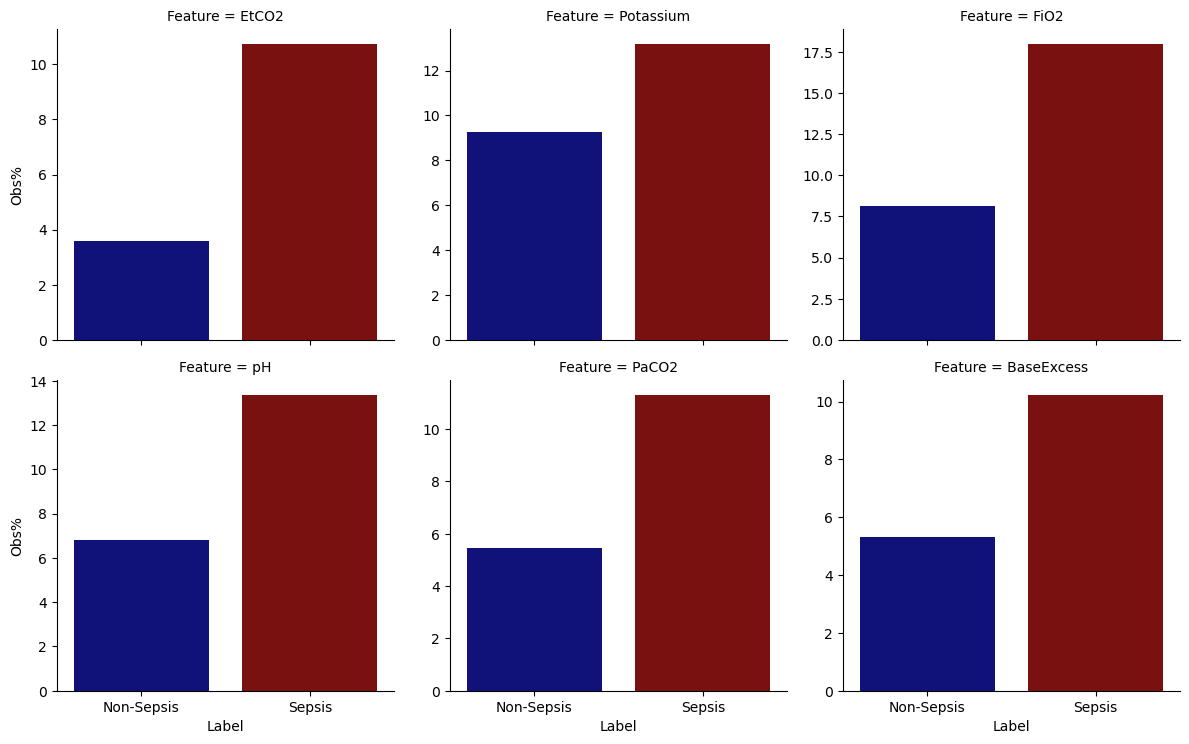

Feature
AST                 1.648293
Alkalinephos        1.649572
BUN                 2.236037
BaseExcess          4.907265
Bilirubin_direct    0.278497
Bilirubin_total     1.420832
Calcium             2.783290
Chloride            2.358956
Creatinine          1.683905
DBP                 1.494612
EtCO2               7.160478
FiO2                9.842368
Fibrinogen          0.533116
Glucose             1.156929
HCO3                2.036460
HR                  1.970019
Hct                 2.418960
Hgb                 2.282121
MAP                 3.008527
Magnesium           2.308090
O2Sat               2.766922
PaCO2               5.858115
Phosphate           1.915508
Platelets           1.611064
Potassium           3.952301
Resp                1.028850
SBP                 0.635076
Temp                0.102374
TroponinI           0.198681
WBC                 1.961472
pH                  6.562191
Name: diff, dtype: float64


In [6]:
pivot_df = plot_df.pivot(index='Feature', columns='Label', values='Obs%')

pivot_df['diff'] = abs(pivot_df['Sepsis'] - pivot_df['Non-Sepsis'])

top_features = pivot_df.sort_values('diff', ascending=False).head(6).index

filtered_df = plot_df[plot_df['Feature'].isin(top_features)]

plot = sns.catplot(
    data=filtered_df,
    kind="bar",
    x="Label",
    y="Obs%",
    hue="Label",
    col="Feature",
    col_wrap=3,
    height=4,
    aspect=1,
    palette={'Sepsis':'darkred','Non-Sepsis':'darkblue'},
    sharey=False,
    legend=False
)

plot.fig.subplots_adjust(top=0.9)

plt.show()

print(pivot_df['diff'])

### ICU unit analysis

In [7]:
# Unit1 vs Sepsis
unit1_table = pd.crosstab(df['Unit1'], df['SepsisLabel'])

chi2_u1, p_u1, _, _ = chi2_contingency(unit1_table)

print("Unit1 vs SepsisLabel")
print(unit1_table)
print(f"Chi²: {chi2_u1:.4f}, p-value: {p_u1:.4e}\n")

# Unit2 vs Sepsis
unit2_table = pd.crosstab(df['Unit2'], df['SepsisLabel'])

chi2_u2, p_u2, _, _ = chi2_contingency(unit2_table)

print("Unit2 vs SepsisLabel")
print(unit2_table)
print(f"Chi²: {chi2_u2:.4f}, p-value: {p_u2:.4e}")

Unit1 vs SepsisLabel
SepsisLabel       0     1
Unit1                    
0.0          466972  6197
1.0          457399  9118
Chi²: 608.7960, p-value: 2.0447e-134

Unit2 vs SepsisLabel
SepsisLabel       0     1
Unit2                    
0.0          457399  9118
1.0          466972  6197
Chi²: 608.7960, p-value: 2.0447e-134


### ICU stay distribution by unit

In [8]:
# Create unit group variable
df['unit_group'] = 'other'

df.loc[(df['Unit1'].isna()) & (df['Unit2'].isna()), 'unit_group'] = 'nan-nan'
df.loc[(df['Unit1'] == 0) & (df['Unit2'] == 1), 'unit_group'] = '0-1'
df.loc[(df['Unit1'] == 1) & (df['Unit2'] == 0), 'unit_group'] = '1-0'

df_filtered = df[df['unit_group'].isin(['nan-nan', '0-1', '1-0'])]

df_iculos = df_filtered.dropna(subset=['ICULOS'])

### ICU LOS visualization

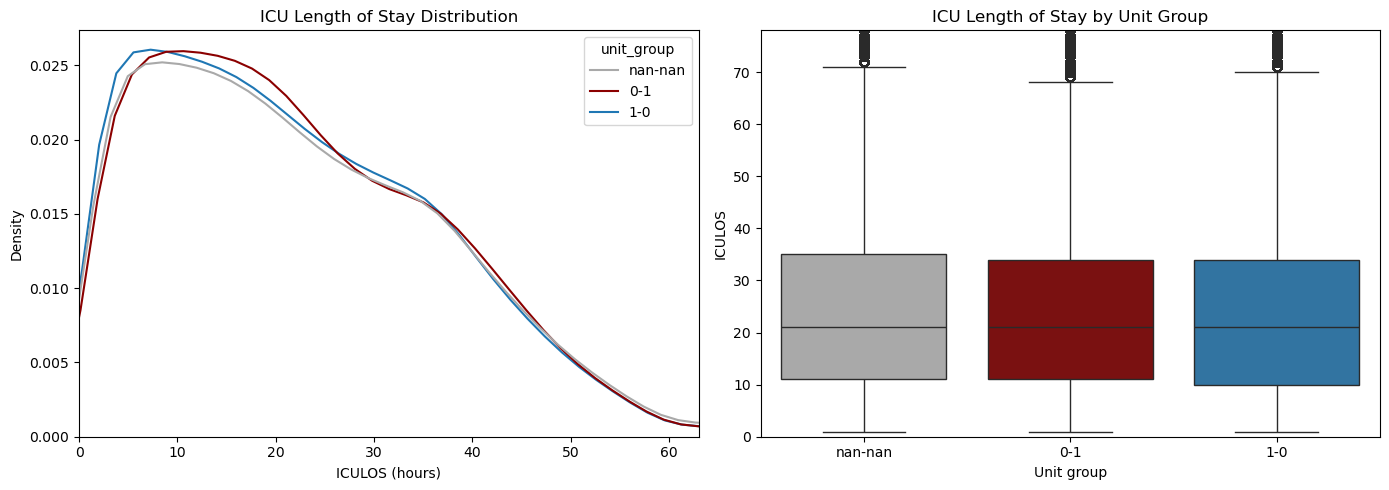

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.kdeplot(
    data=df_iculos,
    x='ICULOS',
    hue='unit_group',
    common_norm=False,
    ax=axes[0],
    palette={'nan-nan':'darkgrey','0-1':'darkred','1-0':'#1f77b4'}
)

axes[0].set_title("ICU Length of Stay Distribution")
axes[0].set_xlabel("ICULOS (hours)")
axes[0].set_xlim(0, df_iculos['ICULOS'].quantile(0.95))

sns.boxplot(
    data=df_iculos,
    x='unit_group',
    y='ICULOS',
    hue='unit_group',
    ax=axes[1],
    palette={'nan-nan':'darkgrey','0-1':'darkred','1-0':'#1f77b4'},
    legend=False
)

axes[1].set_title("ICU Length of Stay by Unit Group")
axes[1].set_xlabel("Unit group")

plt.ylim(0, df_iculos['ICULOS'].quantile(0.96))

plt.tight_layout()
plt.show()

### Remove ICU unit variables

In [10]:
df.drop(['Unit1','Unit2','unit_group'], axis=1, inplace=True)

### Patient observation index

In [11]:
df['lp'] = df.groupby('patient_ID').cumcount()

### Variables with >95% missing values

In [12]:
columns_to_drop = [
    'Bilirubin_direct','Chloride','Fibrinogen','TroponinI',
    'Bilirubin_total','Alkalinephos','AST','Phosphate',
    'SaO2','HCO3','Lactate','PTT','ICULOS'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

print("Remaining variables after removing features with >95% missing values:")
print(df.columns.tolist())

Remaining variables after removing features with >95% missing values:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'FiO2', 'pH', 'PaCO2', 'BUN', 'Calcium', 'Creatinine', 'Glucose', 'Magnesium', 'Potassium', 'Hct', 'Hgb', 'WBC', 'Platelets', 'Age', 'Gender', 'HospAdmTime', 'SepsisLabel', 'patient_ID', 'lp']


### Replace physiologically impossible values

In [13]:
# Physiological ranges
ranges = {
    'BUN': (1,100),
    'BaseExcess': (-10,10),
    'Calcium': (5.5,14),
    'Creatinine': (0.1,10),
    'DBP': (30,150),
    'EtCO2': (15,70),
    'FiO2': (0.21,1.0),
    'Glucose': (30,500),
    'HR': (30,220),
    'Hct': (10,60),
    'Hgb': (3,20),
    'MAP': (40,200),
    'Magnesium': (1.0,4.0),
    'O2Sat': (50,100),
    'PaCO2': (20,70),
    'Platelets': (30,800),
    'Potassium': (2.5,6.5),
    'Resp': (5,60),
    'SBP': (50,250),
    'Temp': (30,43),
    'WBC': (0.5,150),
    'pH': (7.0,7.8)
}

invalid_counts = {}

for col, (low, high) in ranges.items():

    if col in df.columns:

        out_range = (df[col] < low) | (df[col] > high)

        invalid_counts[col] = out_range.sum()

invalid_df = pd.DataFrame.from_dict(
    invalid_counts,
    orient='index',
    columns=['Number of invalid values']
)

invalid_df = invalid_df.sort_values(
    'Number of invalid values',
    ascending=False
)

print("\nSummary of values outside physiological ranges:")
print(invalid_df)


Summary of values outside physiological ranges:
            Number of invalid values
Calcium                        11853
BaseExcess                      2631
MAP                             1669
DBP                             1654
PaCO2                           1540
BUN                             1193
EtCO2                           1107
Potassium                       1013
Creatinine                       851
Platelets                        821
FiO2                             395
SBP                              382
Magnesium                        298
Glucose                          285
O2Sat                            272
WBC                              185
pH                               139
HR                               137
Resp                             119
Hgb                               48
Hct                               34
Temp                              18


### Replace invalid values with NaN

In [14]:
for col, (low, high) in ranges.items():

    if col in df.columns:

        df.loc[(df[col] < low) | (df[col] > high), col] = np.nan

### Imputation for physiological variables (LOCF)

In [15]:
vars_to_impute = ['HR','MAP','Temp','Resp','O2Sat','SBP','DBP']

df = df.sort_values(['patient_ID','lp'])

def impute_locf(group):

    for col in vars_to_impute:

        group[col] = group[col].ffill()

    return group

df = df.groupby('patient_ID', group_keys=False).apply(impute_locf)

C:\Users\karol\AppData\Local\Temp\ipykernel_23732\697655646.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('patient_ID', group_keys=False).apply(impute_locf)


### Remove rows with remaining missing values

In [16]:
print("Rows before removing missing values:", df.shape[0])

df = df.dropna(subset=vars_to_impute)

print("Rows after removing missing values:", df.shape[0])

print("\nRemaining missing values:\n",
      df[vars_to_impute].isnull().sum())

Rows before removing missing values: 1551446
Rows after removing missing values: 1153763

Remaining missing values:
 HR       0
MAP      0
Temp     0
Resp     0
O2Sat    0
SBP      0
DBP      0
dtype: int64


### Dataset preparation with MICE and missingness masks

In [17]:
MASK_COLS = ['EtCO2','FiO2','PaCO2','pH','BaseExcess','Potassium']

MICE_ONLY = [
    'Glucose','Hct','Hgb','BUN',
    'Magnesium','Creatinine','WBC',
    'Calcium','Platelets'
]

In [18]:
def prep_mice_masks_split(df, label='SepsisLabel', test_size=0.2, random_state=42):

    drop_cols = [c for c in ['patient_ID','lp','unit_group',label] if c in df.columns]

    X = df.drop(columns=drop_cols, errors='ignore').copy()
    y = df[label].astype(int)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        stratify=y,
        test_size=test_size,
        random_state=random_state
    )

    mask_cols = [c for c in MASK_COLS if c in X.columns]
    mice_cols = [c for c in MICE_ONLY if c in X.columns]

    cols_to_impute = list(dict.fromkeys(mask_cols + mice_cols))


    tr_mask = (
        X_tr[mask_cols].isna().astype('int8').add_suffix('_is_missing')
        if mask_cols else pd.DataFrame(index=X_tr.index)
    )

    te_mask = (
        X_te[mask_cols].isna().astype('int8').add_suffix('_is_missing')
        if mask_cols else pd.DataFrame(index=X_te.index)
    )
    if cols_to_impute:

        imputer = IterativeImputer(
            random_state=random_state,
            max_iter=20,
            sample_posterior=True,
            initial_strategy='median'
        )

        Xtr_imp_part = pd.DataFrame(
            imputer.fit_transform(X_tr[cols_to_impute]),
            columns=cols_to_impute,
            index=X_tr.index
        )

        Xte_imp_part = pd.DataFrame(
            imputer.transform(X_te[cols_to_impute]),
            columns=cols_to_impute,
            index=X_te.index
        )

        X_tr_proc = pd.concat(
            [X_tr.drop(columns=cols_to_impute), Xtr_imp_part, tr_mask],
            axis=1
        )

        X_te_proc = pd.concat(
            [X_te.drop(columns=cols_to_impute), Xte_imp_part, te_mask],
            axis=1
        )

    else:

        X_tr_proc = pd.concat([X_tr, tr_mask], axis=1)
        X_te_proc = pd.concat([X_te, te_mask], axis=1)

    X_te_proc = X_te_proc.reindex(columns=X_tr_proc.columns, fill_value=0)

    return X_tr_proc, X_te_proc, y_tr, y_te


### Generate train and test sets with MCIE to avoid data leakage

In [19]:
X_tr, X_te, y_tr, y_te = prep_mice_masks_split(df, label='SepsisLabel')

### Dataset preparation for modeling

### Generate modeling datasets

In [20]:
X_tr.to_csv("X_train.csv", index=False)
X_te.to_csv("X_test.csv", index=False)

y_tr.to_csv("y_train.csv", index=False)
y_te.to_csv("y_test.csv", index=False)

### Full dataset with NaN + masks

In [21]:
# Variables for missingness masks
cols = [
    'EtCO2','FiO2','PaCO2','pH','BaseExcess','Potassium',
    'Glucose','Hct','Hgb','BUN','Magnesium',
    'Creatinine','WBC','Calcium','Platelets'
]

# Missingness masks (1 = missing, 0 = observed)
missing_masks = df[cols].isna().astype('int8').add_suffix('_miss')

# Combine original data with masks
df_model_full = pd.concat([df, missing_masks], axis=1)

# Save dataset
df_model_full.to_csv("df_model_full.csv", index=False)